<a href="https://colab.research.google.com/github/papasega/DeepLearning_Shared_PSW/blob/main/psw-Deblurring_PnP_DnCNN_FB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook created on Wed Sept 7 2025 by Nelly Pustelnik and Audrey Repetti


This webpage provides basics codes to perform image reconstruction tasks with DeepInverse library (https://deepinv.github.io/deepinv/). For the first use of this tutorial code, you should install it :

In [ ]:
pip install git+https://github.com/deepinv/deepinv.git#egg=deepinv

  Cloning https://github.com/deepinv/deepinv.git to /tmp/pip-install-zzj52qlt/deepinv_4e9545b8f4ae4f6f94b3207a0788eb2d
  Running command git clone --filter=blob:none --quiet https://github.com/deepinv/deepinv.git /tmp/pip-install-zzj52qlt/deepinv_4e9545b8f4ae4f6f94b3207a0788eb2d
  Resolved https://github.com/deepinv/deepinv.git to commit 4a55a25a95d0ccdd8a98a06da7428803dfef9923
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 19.6 MB/s eta 0:00:00
  Created wheel for deepinv: filename=deepinv-0.3.3-py3-none-any.whl size=752022 sha256=76b7dc2efe84faaefbce2507d0bcb9b26f3b9253d55e0b157f1c36de4ced6f15
  Stored in directory: /tmp/pip-ephem-wheel-cache-obme81tp/wheels/84/8d/78/3f46551e7c8c141353bd628df44fbeb33820f3b5a4a2da7e2a
Successfully built deepinv


Import python libraries :

In [ ]:
import deepinv as dinv                  # Import DeepInverse
import torch                            # Import Pytorch
from torchvision.io import read_image   # Import tool to read image
import numpy as np                      # Import numpy to basic computations
import matplotlib.pyplot as plt         # Import matplotlib to plot results
from deepinv.loss.metric import PSNR    # Import PSNR to easily evaluate it
perf_psnr = PSNR()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



# Image Restoration in the presence of Gaussian noise: *Solving with FB-PnP*


The forward model is:
$$\mathbf{z} = \mathcal{D} \big( {\Phi} \overline{\mathbf{x}} \big)$$

with
* $\overline{\mathbf{x}}$ : the original image
* $\mathbf{z}$ : the degraded image
* ${\Phi}$ : a linear operator. Here a blur.
* $\mathcal{D}$ : the stochatic degradation (i.e., noise). Here a white Gaussian noise.

We first download the image :

In [ ]:
image_path = "https://perso.ens-lyon.fr/nelly.pustelnik/PNN/images/393035.jpg"
url = (image_path)
x_true = dinv.utils.load_url_image(url=url, img_size=100).to(device)

Then, we define the forward operator ${\Phi}$ in the context of deblurring and add Gaussian noise. Different types of forward operator ${\Phi}$ can be easily generated with DeepInverse.
See the [full list is of available
operators](https://deepinv.github.io/deepinv/deepinv.physics.html).



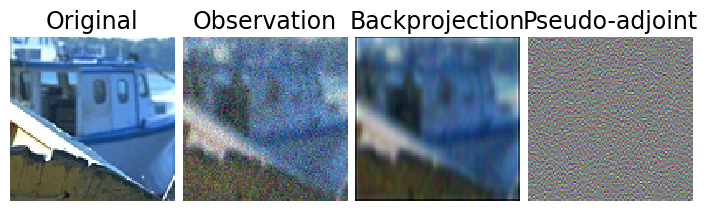

In [ ]:
# Convolution forward model
filter_0 = dinv.physics.blur.gaussian_blur(sigma=(2, 0.9), angle=0.0)
physics = dinv.physics.Blur(filter_0, device=device, padding='reflect')

# Add noise in the forward model
physics.noise_model = dinv.physics.GaussianNoise(sigma=0.1)

y = physics(x_true)
back = physics.A_adjoint(y)
pseudo = physics.A_dagger(y)
dinv.utils.plot([x_true, y, back, pseudo], titles=['Original','Observation','Backprojection','Pseudo-adjoint'])


The knowledge of the norm of the forward operator $\Phi$ is often required in proximal algorithms. We describe how to easily compute it with DeepInverse.

In [ ]:
tensor_shape = x_true.shape
random_tensor = torch.randn(tensor_shape).to(device)
Anorm2 = physics.compute_norm(random_tensor)
print(f"Anorm2: {Anorm2}")

Power iteration converged at iteration 24, value=1.00
Anorm2: 0.9993159770965576


In this notebook, we consider PnP forward-backward (FB) iterations

$$\begin{array}{l}
\text{For } k = 0, 1, \ldots \\
\left\lfloor
\begin{array}{l}
\mathbf{x}^{[k+1]} = \mathfrak{D}_{\Lambda_k} \big(  \mathbf{x}^{[k]} -\tau \Phi^* (\Phi \mathbf{u}^{[k]}  - \mathbf{z})\big)	\\
\end{array}
\right.
\end{array}$$
where $\mathfrak{D}_{\Lambda_k} $ denotes a DnCNN denoiser.

In [ ]:

# Define data fidelity term
data_fidelity = dinv.optim.L2()

# Define prior
denoiser = dinv.models.DnCNN(in_channels=3, out_channels=3, pretrained="download_lipschitz", device=device)
prior = dinv.optim.prior.PnP(denoiser=denoiser)

# Define regularization parameter
param_regul    = 0.01;

# Define algorithm parameters
random_tensor   = torch.randn(x_true.shape).to(device)
Anorm2          = physics.compute_norm(random_tensor)
param_gamma     = 0.1/ Anorm2         # Set the step-size
param_iter      = 500                 # number of iterations

# Iterations
xk = back.clone()
crit = 1e10*np.ones(param_iter)
psnr = 1e10*np.ones(param_iter)
with torch.no_grad():
    for k in range(param_iter):
        xk_prev = xk.clone()

        xk = xk - param_gamma*data_fidelity.grad(xk, y, physics)
        xk = prior.prox(xk, sigma_denoiser = param_gamma*param_regul)

        crit[k] = torch.linalg.norm(xk.flatten()-xk_prev.flatten())
        psnr[k] = perf_psnr(x_true,xk).item()
        if k % 10 == 0: print(f"crit[{k}]: {crit[k]}")


Power iteration converged at iteration 26, value=1.00
crit[0]: 0.5372527241706848
crit[10]: 0.2307586371898651
crit[20]: 0.1416579633951187
crit[30]: 0.09912094473838806
crit[40]: 0.07621823996305466
crit[50]: 0.06273390352725983
crit[60]: 0.05412302538752556
crit[70]: 0.048419490456581116
crit[80]: 0.044481951743364334
crit[90]: 0.04151274636387825
crit[100]: 0.03898775205016136
crit[110]: 0.03678270801901817
crit[120]: 0.034604284912347794
crit[130]: 0.03283567726612091
crit[140]: 0.03176372870802879
crit[150]: 0.03139490261673927
crit[160]: 0.03134819120168686
crit[170]: 0.030949274078011513
crit[180]: 0.030133647844195366
crit[190]: 0.029103372246026993
crit[200]: 0.02804916352033615
crit[210]: 0.026270952075719833
crit[220]: 0.02475122921168804
crit[230]: 0.024288184940814972
crit[240]: 0.023877382278442383
crit[250]: 0.02315651997923851
crit[260]: 0.022091872990131378
crit[270]: 0.017277803272008896
crit[280]: 0.014368086121976376
crit[290]: 0.013059752993285656
crit[300]: 0.0122

Display reconstruction results :

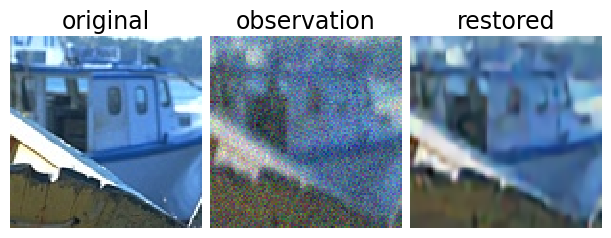

/tmp/ipython-input-1624358474.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()
/tmp/ipython-input-1624358474.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


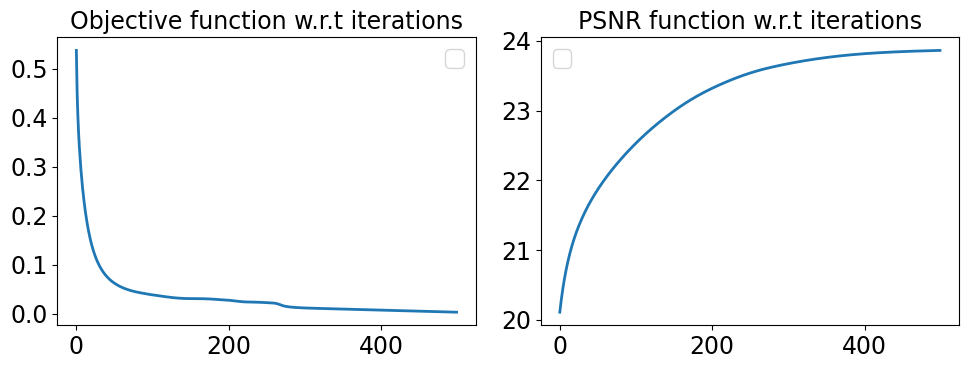

In [ ]:
# Display results
dinv.utils.plot([x_true, y, xk], titles=['original','observation','restored'],figsize=[6,18])
fig, axs = plt.subplots(1, 2, figsize=(10, 4))  # 2 lignes, 1 colonne
axs[0].plot(crit)
axs[0].legend()
axs[0].set_title('Objective function w.r.t iterations')
axs[1].plot(psnr)
axs[1].legend()
axs[1].set_title('PSNR function w.r.t iterations')
plt.tight_layout()
plt.show()
